In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler



In [2]:
df= pd.read_csv('task1_dataset.csv')
df.head()

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,2020-01-01,63,63013.191704,279389.811431,616.029633,31,6.904324e+05,Bangalore,Unemployed,Auto,294319.227774
1,2020-01-02,20,47161.859481,950897.454063,716.561294,33,5.951086e+05,Bangalore,Student,Home,154516.648673
2,2020-01-03,46,55234.345094,NaN,564.991196,28,9.989912e+05,Delhi,Student,Auto,252354.507062
3,2020-01-04,52,74712.765160,431159.014692,572.736033,25,7.007800e+05,Chennai,Unemployed,Home,226719.203929
4,2020-01-05,56,82830.588108,272730.054365,813.630055,34,1.105784e+06,Delhi,Unemployed,Home,225838.346929


In [3]:
df.columns

Index(['date', 'age', 'income', 'loan_amount', 'credit_score',
       'num_transactions', 'annual_spend', 'city', 'employment_type',
       'loan_type', 'target'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              2000 non-null   object 
 1   age               2000 non-null   int64  
 2   income            1920 non-null   float64
 3   loan_amount       1920 non-null   float64
 4   credit_score      1920 non-null   float64
 5   num_transactions  2000 non-null   int64  
 6   annual_spend      1920 non-null   float64
 7   city              2000 non-null   object 
 8   employment_type   2000 non-null   object 
 9   loan_type         2000 non-null   object 
 10  target            2000 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 172.0+ KB


In [5]:
df['income'].fillna(df['income'].mean(), inplace=True)
df['loan_amount'].fillna(df['loan_amount'].mean(), inplace=True)
df['credit_score'].fillna(df['credit_score'].mean(), inplace=True)

C:\Users\Brahm\AppData\Local\Temp\ipykernel_25160\1291295795.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(df['income'].mean(), inplace=True)
C:\Users\Brahm\AppData\Local\Temp\ipykernel_25160\1291295795.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [6]:
df.describe()

,age,income,loan_amount,credit_score,num_transactions,annual_spend,target
count,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.00000,1.920000e+03,2000.000000
mean,43.569500,64111.180976,3.135794e+05,649.451886,30.13600,1.081605e+06,246455.466965
std,14.892786,34620.351326,1.386892e+05,78.856615,5.24006,7.028877e+05,66306.121409
min,18.000000,-5135.359342,-2.336766e+04,373.096400,14.00000,-1.461650e+05,13300.170171
25%,31.000000,47503.042095,2.374651e+05,596.083986,27.00000,7.887255e+05,201830.604797
50%,43.000000,61727.909786,3.094607e+05,649.451886,30.00000,1.004297e+06,245424.498558
75%,56.000000,74654.555187,3.684685e+05,700.293214,33.00000,1.214651e+06,292110.550126
max,69.000000,426093.266439,1.525158e+06,919.903709,52.00000,7.541094e+06,478502.472525


In [7]:
df.isnull().sum()

date                 0
age                  0
income               0
loan_amount          0
credit_score         0
num_transactions     0
annual_spend        80
city                 0
employment_type      0
loan_type            0
target               0
dtype: int64

In [8]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) & (df[column] <= upper)]

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df = remove_outliers(df, col)

print("\nAfter Removing Outliers:")
print(df.shape)


After Removing Outliers:
(1736, 11)


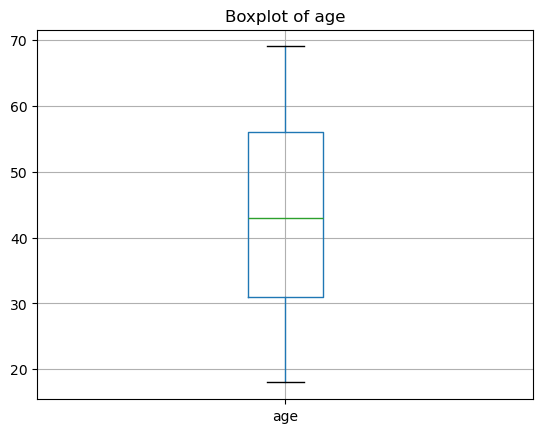

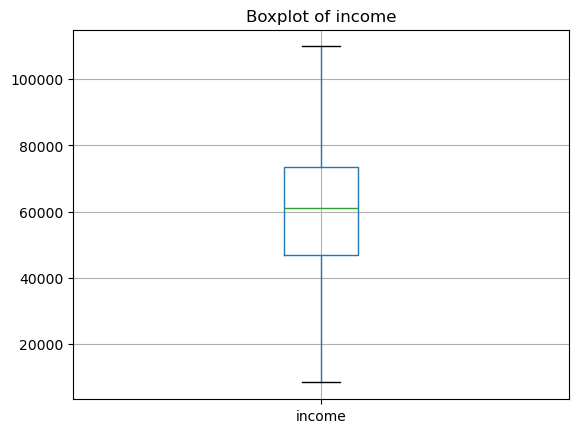

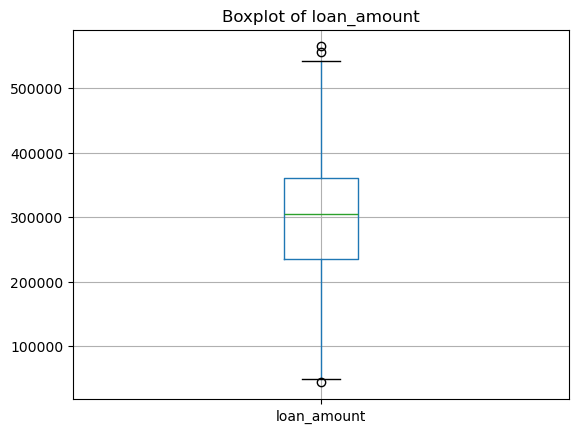

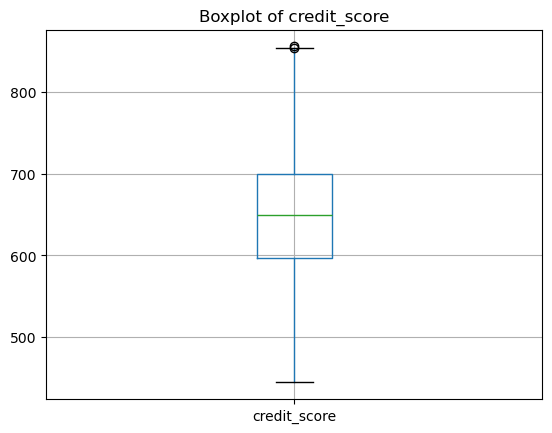

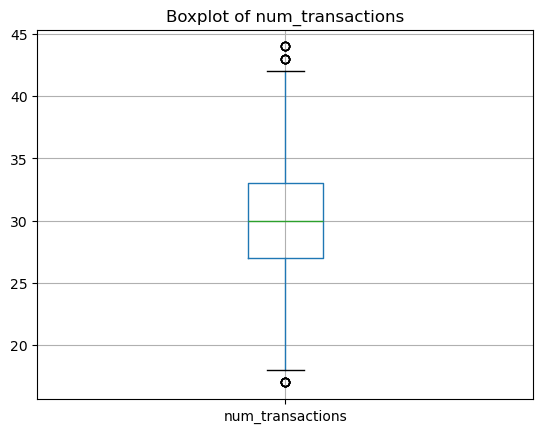

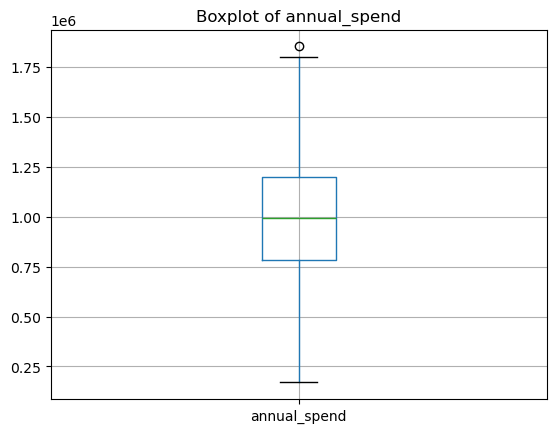

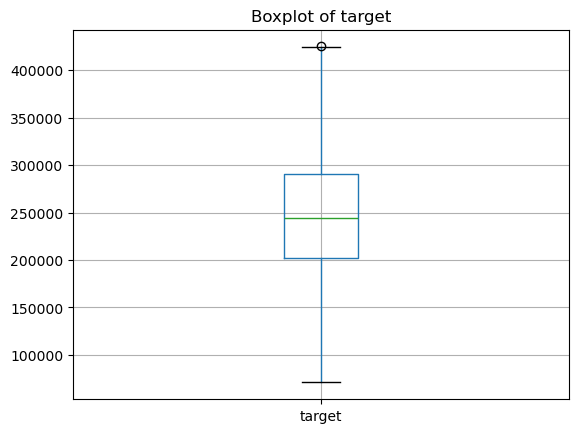

In [9]:
for col in num_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()


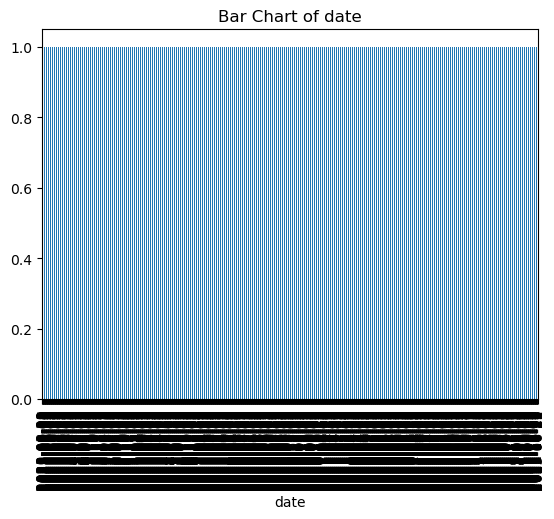

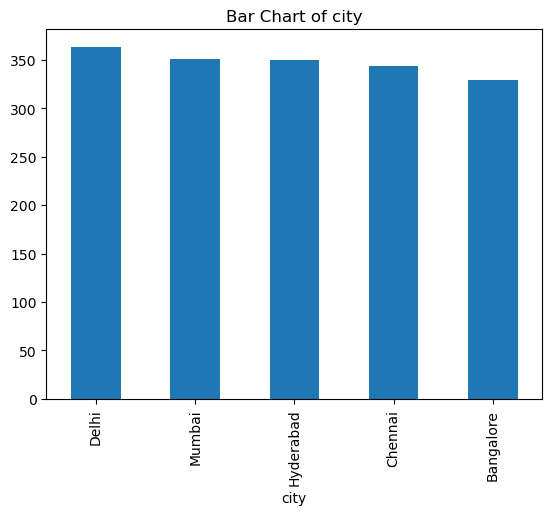

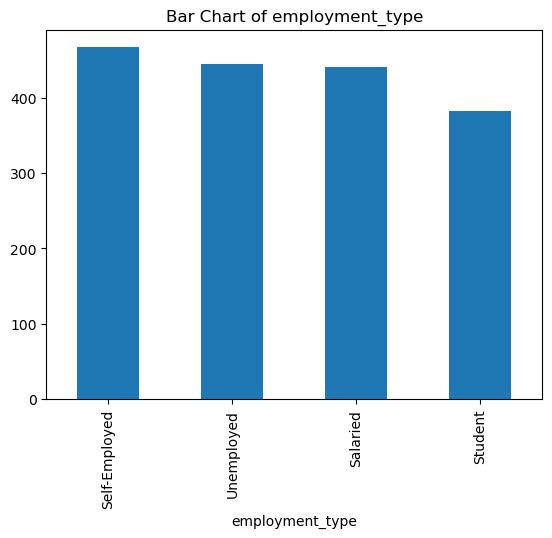

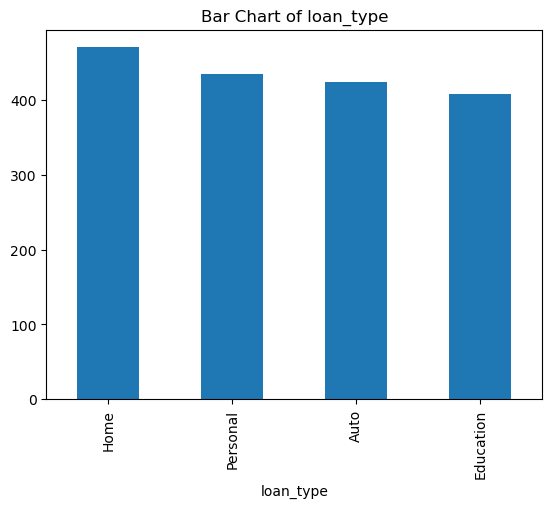

In [10]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Bar Chart of {col}")
    plt.savefig(f"bar_{col}.png")
    plt.show()


In [11]:
print("\nFinal Processed Dataset:")
print(df.head())


Final Processed Dataset:
         date  age        income    loan_amount  credit_score  \
0  2020-01-01   63  63013.191704  279389.811431    616.029633   
2  2020-01-03   46  55234.345094  313579.376380    564.991196   
3  2020-01-04   52  74712.765160  431159.014692    572.736033   
4  2020-01-05   56  82830.588108  272730.054365    813.630055   
5  2020-01-06   35  51850.084382  358787.410069    653.483969   

   num_transactions  annual_spend       city employment_type  loan_type  \
0                31  6.904324e+05  Bangalore      Unemployed       Auto   
2                28  9.989912e+05      Delhi         Student       Auto   
3                25  7.007800e+05    Chennai      Unemployed       Home   
4                34  1.105784e+06      Delhi      Unemployed       Home   
5                44  1.060460e+06  Bangalore   Self-Employed  Education   

          target  
0  294319.227774  
2  252354.507062  
3  226719.203929  
4  225838.346929  
5  222714.888194  


In [12]:
# Select numerical columns
num_cols = ["age", "income", "loan_amount", "credit_score"]

# Remove outliers using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df)

            date  age        income    loan_amount  credit_score  \
0     2020-01-01   63  63013.191704  279389.811431    616.029633   
2     2020-01-03   46  55234.345094  313579.376380    564.991196   
3     2020-01-04   52  74712.765160  431159.014692    572.736033   
4     2020-01-05   56  82830.588108  272730.054365    813.630055   
5     2020-01-06   35  51850.084382  358787.410069    653.483969   
...          ...  ...           ...            ...           ...   
1993  2025-06-16   19  39430.012538  233760.051426    555.212904   
1996  2025-06-19   41  63361.024697  305509.307595    546.198231   
1997  2025-06-20   50  60798.190941  259602.205191    639.065695   
1998  2025-06-21   35  56771.242421  329666.713399    578.375678   
1999  2025-06-22   57  64111.180976  444601.957311    661.118379   

      num_transactions  annual_spend       city employment_type  loan_type  \
0                   31  6.904324e+05  Bangalore      Unemployed       Auto   
2                   28  9.9

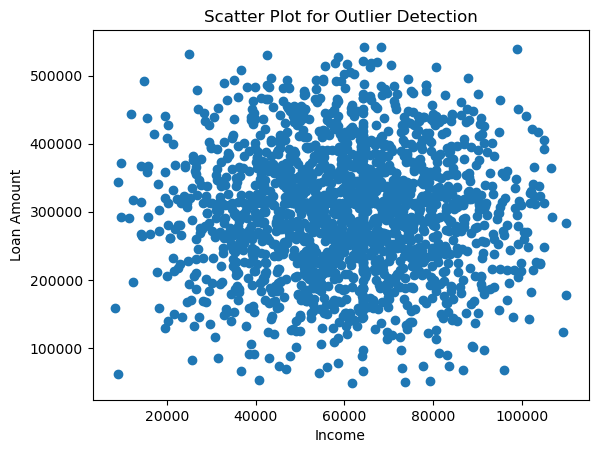

In [13]:
# Scatter plot: Income vs Loan Amount
plt.scatter(df["income"], df["loan_amount"])

plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.title("Scatter Plot for Outlier Detection")

plt.show()

In [14]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nColumn: {col}")
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)


Column: age
Lower Bound: -6.5
Upper Bound: 93.5

Column: income
Lower Bound: 7119.630185726106
Upper Bound: 113262.09613505978

Column: loan_amount
Lower Bound: 45503.11175791951
Upper Bound: 549247.81982615

Column: credit_score
Lower Bound: 442.61435838241675
Upper Bound: 853.5891034148843

Column: num_transactions
Lower Bound: 18.0
Upper Bound: 42.0

Column: annual_spend
Lower Bound: 162694.01966019406
Upper Bound: 1820264.8761367165

Column: target
Lower Bound: 68372.27813711413
Upper Bound: 424375.376746441


In [15]:
outliers = df[(df['income'] < lower_bound) | (df['income'] > upper_bound)]
print(outliers)

            date  age        income    loan_amount  credit_score  \
0     2020-01-01   63  63013.191704  279389.811431    616.029633   
2     2020-01-03   46  55234.345094  313579.376380    564.991196   
5     2020-01-06   35  51850.084382  358787.410069    653.483969   
9     2020-01-10   51  33225.335552  290629.230910    548.091649   
11    2020-01-12   67  52501.460154  144132.655519    767.655996   
...          ...  ...           ...            ...           ...   
1993  2025-06-16   19  39430.012538  233760.051426    555.212904   
1996  2025-06-19   41  63361.024697  305509.307595    546.198231   
1997  2025-06-20   50  60798.190941  259602.205191    639.065695   
1998  2025-06-21   35  56771.242421  329666.713399    578.375678   
1999  2025-06-22   57  64111.180976  444601.957311    661.118379   

      num_transactions  annual_spend       city employment_type  loan_type  \
0                   31  6.904324e+05  Bangalore      Unemployed       Auto   
2                   28  9.9

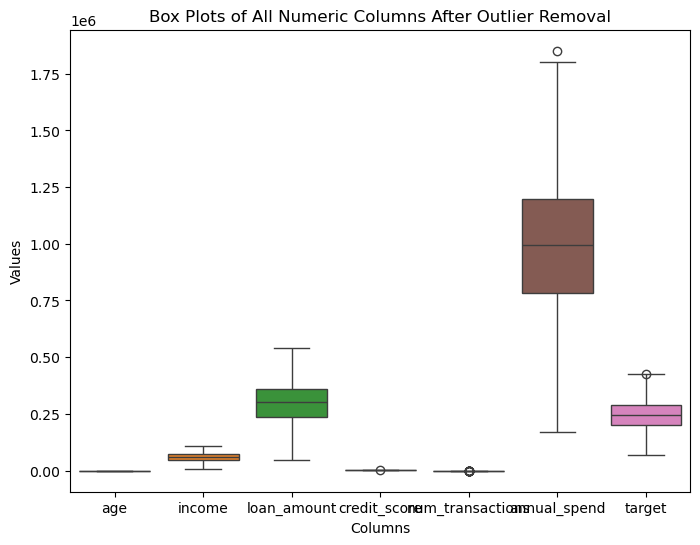

In [16]:
#Create a box plot to visualize the distribution of the all columns after outlier removal
plt.figure(figsize=(8, 6))      
sns.boxplot(data=df[num_cols])
plt.title("Box Plots of All Numeric Columns After Outlier Removal")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()

In [17]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

skew_values = df[num_cols].skew()

print(skew_values)

age                -0.007668
income             -0.047086
loan_amount        -0.027264
credit_score       -0.005121
num_transactions    0.100545
annual_spend        0.008989
target              0.001163
dtype: float64


In [18]:
for col in num_cols:
    skew = df[col].skew()
    
    if -0.5 <= skew <= 0.5:
        print(f"{col} ➝ Normal Distribution (Skew={skew:.2f})")
    elif skew > 0.5:
        print(f"{col} ➝ Positively Skewed (Right Skewed) (Skew={skew:.2f})")
    else:
        print(f"{col} ➝ Negatively Skewed (Left Skewed) (Skew={skew:.2f})")

age ➝ Normal Distribution (Skew=-0.01)
income ➝ Normal Distribution (Skew=-0.05)
loan_amount ➝ Normal Distribution (Skew=-0.03)
credit_score ➝ Normal Distribution (Skew=-0.01)
num_transactions ➝ Normal Distribution (Skew=0.10)
annual_spend ➝ Normal Distribution (Skew=0.01)
target ➝ Normal Distribution (Skew=0.00)


In [19]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns
skewness = df[num_cols].skew()

In [20]:
# Better condition for normal (instead of == 0)
normal_skewed_features = skewness[(skewness >= -0.5) & (skewness <= 0.5)].index.tolist()

positive_skewed_features = skewness[skewness > 0.5].index.tolist()

negative_skewed_features = skewness[skewness < -0.5].index.tolist()

print("Normal skewed features: ", normal_skewed_features)
print("Positive skewed features: ", positive_skewed_features)
print("Negative skewed features: ", negative_skewed_features)

Normal skewed features:  ['age', 'income', 'loan_amount', 'credit_score', 'num_transactions', 'annual_spend', 'target']
Positive skewed features:  []
Negative skewed features:  []


In [21]:
print(skewness)

age                -0.007668
income             -0.047086
loan_amount        -0.027264
credit_score       -0.005121
num_transactions    0.100545
annual_spend        0.008989
target              0.001163
dtype: float64


In [22]:
normal_skew=['income','lean_amount']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])
df.head()

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,2020-01-01,0.882353,0.538148,0.467653,0.418527,0.518519,0.309251,Bangalore,Unemployed,Auto,0.630758
2,2020-01-03,0.549020,0.461533,0.536873,0.293761,0.407407,0.492861,Delhi,Student,Auto,0.512318
3,2020-01-04,0.666667,0.653380,0.774923,0.312694,0.296296,0.315408,Chennai,Unemployed,Home,0.439965
4,2020-01-05,0.745098,0.733334,0.454169,0.901571,0.629630,0.556409,Delhi,Unemployed,Home,0.437479
5,2020-01-06,0.333333,0.428201,0.628400,0.510086,1.000000,0.529439,Bangalore,Self-Employed,Education,0.428664


In [23]:
# check the normal , postive skewness and negative skewness features
normal_skewed_features = skewness[skewness == 0].index.tolist()
positive_skewed_features = skewness[skewness > 0].index.tolist()
negative_skewed_features = skewness[skewness < 0].index.tolist()
 
print("Normal skewed features: ", normal_skewed_features)
print("Positive skewed features: ", positive_skewed_features)
print("Negative skewed features: ", negative_skewed_features)

Normal skewed features:  []
Positive skewed features:  ['num_transactions', 'annual_spend', 'target']
Negative skewed features:  ['age', 'income', 'loan_amount', 'credit_score']


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["credit_score"] = scaler.fit_transform(df[["credit_score"]])
df.head()

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,2020-01-01,0.882353,0.538148,0.467653,-0.445298,0.518519,0.309251,Bangalore,Unemployed,Auto,0.630758
2,2020-01-03,0.549020,0.461533,0.536873,-1.125197,0.407407,0.492861,Delhi,Student,Auto,0.512318
3,2020-01-04,0.666667,0.653380,0.774923,-1.022026,0.296296,0.315408,Chennai,Unemployed,Home,0.439965
4,2020-01-05,0.745098,0.733334,0.454169,2.186998,0.629630,0.556409,Delhi,Unemployed,Home,0.437479
5,2020-01-06,0.333333,0.428201,0.628400,0.053642,1.000000,0.529439,Bangalore,Self-Employed,Education,0.428664


In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = ['age','income','loan_amount','credit_score','target']

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,2020-01-01,0.882353,0.538148,0.467653,0.418527,0.518519,0.309251,Bangalore,Unemployed,Auto,0.630758
2,2020-01-03,0.549020,0.461533,0.536873,0.293761,0.407407,0.492861,Delhi,Student,Auto,0.512318
3,2020-01-04,0.666667,0.653380,0.774923,0.312694,0.296296,0.315408,Chennai,Unemployed,Home,0.439965
4,2020-01-05,0.745098,0.733334,0.454169,0.901571,0.629630,0.556409,Delhi,Unemployed,Home,0.437479
5,2020-01-06,0.333333,0.428201,0.628400,0.510086,1.000000,0.529439,Bangalore,Self-Employed,Education,0.428664


In [26]:
# convert True/False to 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# check result
print(df.head())

         date       age    income  loan_amount  credit_score  \
0  2020-01-01  0.882353  0.538148     0.467653      0.418527   
2  2020-01-03  0.549020  0.461533     0.536873      0.293761   
3  2020-01-04  0.666667  0.653380     0.774923      0.312694   
4  2020-01-05  0.745098  0.733334     0.454169      0.901571   
5  2020-01-06  0.333333  0.428201     0.628400      0.510086   

   num_transactions  annual_spend       city employment_type  loan_type  \
0          0.518519      0.309251  Bangalore      Unemployed       Auto   
2          0.407407      0.492861      Delhi         Student       Auto   
3          0.296296      0.315408    Chennai      Unemployed       Home   
4          0.629630      0.556409      Delhi      Unemployed       Home   
5          1.000000      0.529439  Bangalore   Self-Employed  Education   

     target  
0  0.630758  
2  0.512318  
3  0.439965  
4  0.437479  
5  0.428664  


In [30]:
scaler = MinMaxScaler()

num_cols = ['age','income','loan_amount','credit_score','target']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [31]:
X = df.drop("target", axis=1)
y = df["target"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

         date  age        income    loan_amount  credit_score  \
0  2020-01-01   63  63013.191704  279389.811431    616.029633   
1  2020-01-02   20  47161.859481  950897.454063    716.561294   
2  2020-01-03   46  55234.345094            NaN    564.991196   
3  2020-01-04   52  74712.765160  431159.014692    572.736033   
4  2020-01-05   56  82830.588108  272730.054365    813.630055   

   num_transactions  annual_spend       city employment_type loan_type  \
0                31  6.904324e+05  Bangalore      Unemployed      Auto   
1                33  5.951086e+05  Bangalore         Student      Home   
2                28  9.989912e+05      Delhi         Student      Auto   
3                25  7.007800e+05    Chennai      Unemployed      Home   
4                34  1.105784e+06      Delhi      Unemployed      Home   

          target  
0  294319.227774  
1  154516.648673  
2  252354.507062  
3  226719.203929  
4  225838.346929  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

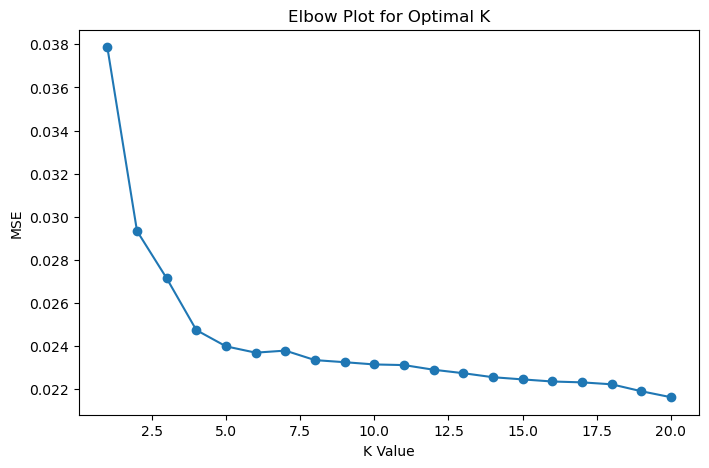

In [36]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("task1_dataset.csv")

# Explore dataset
print(df.head())
print(df.info())

# Handle missing values
df["income"] = df["income"].fillna(df["income"].mean())
df["loan_amount"] = df["loan_amount"].fillna(df["loan_amount"].median())
df["credit_score"] = df["credit_score"].fillna(df["credit_score"].mean())
df["annual_spend"] = df["annual_spend"].fillna(df["annual_spend"].median())

# Drop date column
if "date" in df.columns:
    df.drop("date", axis=1, inplace=True)

# Encode categorical columns automatically
categorical_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=categorical_cols, dtype=int)

# Feature scaling
scaler = MinMaxScaler()
num_cols = ['age','income','loan_amount','credit_score','num_transactions','annual_spend','target']
df[num_cols] = scaler.fit_transform(df[num_cols])

# Split features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train KNN regression model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Elbow method to find best K
mse_values = []
k_values = range(1,21)

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test,pred)
    mse_values.append(mse)

# Plot elbow graph
plt.figure(figsize=(8,5))
plt.plot(k_values, mse_values, marker='o')
plt.xlabel("K Value")
plt.ylabel("MSE")
plt.title("Elbow Plot for Optimal K")
plt.show()